In [ ]:
!pip install autokeras

In [ ]:
import kagglehub
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import autokeras as ak
from sklearn.preprocessing import LabelEncoder
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
import os

## Data Download

In [ ]:
path = kagglehub.dataset_download("sujaykapadnis/smoking")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/smoking


## Data Load

In [ ]:
train_path = path+'/Training/Training'
validation_path = path+'/Validation/Validation'
test_path = path+'/Testing/Testing'

train_fnames = os.listdir(train_path)
validation_fnames = os.listdir(validation_path)
test_fnames = os.listdir(test_path)

In [ ]:
train_fnames

['smoking_0175.jpg',
 'smoking_0480.jpg',
 'notsmoking_0267.jpg',
 'notsmoking_0037.jpg',
 'notsmoking_0379.jpg',
 'notsmoking_0243.jpg',
 'notsmoking_0341.jpg',
 'notsmoking_0245.jpg',
 'notsmoking_0474.jpg',
 'smoking_0248.jpg',
 'smoking_0178.jpg',
 'notsmoking_0001.jpg',
 'smoking_0341.jpg',
 'smoking_0350.jpg',
 'notsmoking_0135.jpg',
 'smoking_0468.jpg',
 'notsmoking_0376.jpg',
 'notsmoking_0139.jpg',
 'smoking_0194.jpg',
 'smoking_0297.jpg',
 'smoking_0221.jpg',
 'notsmoking_0200.jpg',
 'notsmoking_0362.jpg',
 'smoking_0499.jpg',
 'smoking_0376.jpg',
 'smoking_0408.jpg',
 'notsmoking_0210.jpg',
 'notsmoking_0346.jpg',
 'notsmoking_0454.jpg',
 'smoking_0302.jpg',
 'smoking_0052.jpg',
 'smoking_0363.jpg',
 'notsmoking_0464.jpg',
 'notsmoking_0204.jpg',
 'smoking_0267.jpg',
 'smoking_0003.jpg',
 'notsmoking_0552.jpg',
 'smoking_0013.jpg',
 'smoking_0517.jpg',
 'notsmoking_0234.jpg',
 'notsmoking_0009.jpg',
 'notsmoking_0322.jpg',
 'notsmoking_0314.jpg',
 'smoking_0165.jpg',
 'smoki

## Data Preprocessing
AutoKeras에 알맞게 전처리 진행

In [ ]:
def load_images_labels(img_dir):
    images = []
    labels = []
    for fname in os.listdir(img_dir):
        if fname.endswith(".jpg"):
            img = load_img(os.path.join(img_dir, fname), target_size=(150, 150))
            img = img_to_array(img) / 255.0       # scaling the pixel values
            images.append(img)
            if 'notsmoking' in fname:
                labels.append("NotSmoking")
            else:
                labels.append("Smoking")
    return np.array(images), np.array(labels)

In [ ]:
x_train, y_train = load_images_labels(train_path)
x_val, y_val = load_images_labels(validation_path)
x_test, y_test = load_images_labels(test_path)

# change label's type(string) to integer
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

In [ ]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{np.str_('NotSmoking'): np.int64(0), np.str_('Smoking'): np.int64(1)}


## Applying AutoML

In [ ]:
clf = ak.ImageClassifier(max_trials=3, overwrite=True)  # try three CNN architectures
clf.fit(x_train, y_train, epochs=100, validation_data=(x_val, y_val))

Trial 3 Complete [00h 49m 25s]
val_loss: 0.11375519633293152

Best val_loss So Far: 0.11375519633293152
Total elapsed time: 00h 53m 14s
Epoch 1/100
Not enough memory, reduce batch size to 16.
Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.5853 - loss: 0.6796 - val_accuracy: 0.5222 - val_loss: 0.7017
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8063 - loss: 0.5199 - val_accuracy: 0.5278 - val_loss: 0.7036
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8874 - loss: 0.3977 - val_accuracy: 0.5333 - val_loss: 0.6982
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.9147 - loss: 0.2798 - val_accuracy: 0.5778 - val_loss: 0.6605
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.9551 - loss: 0.1904 - val_accuracy: 0.6167 - val_loss: 0.6098
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.9835 - loss: 0.1168 - val_accuracy: 0.7444 - val_loss: 0.5291
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/

In [ ]:
for trial_id, trial in clf.tuner.oracle.trials.items():
    print(f"Trial {trial_id}")
    print("Score:", trial.score)
    print("Hyperparameters:", trial.hyperparameters.values)

Trial 0
Score: 0.5291047692298889
Hyperparameters: {'image_block_1/block_type': 'vanilla', 'image_block_1/normalize': True, 'image_block_1/augment': False, 'image_block_1/conv_block_1/kernel_size': 3, 'image_block_1/conv_block_1/num_blocks': 1, 'image_block_1/conv_block_1/num_layers': 2, 'image_block_1/conv_block_1/max_pooling': True, 'image_block_1/conv_block_1/separable': False, 'image_block_1/conv_block_1/dropout': 0.25, 'image_block_1/conv_block_1/filters_0_0': 32, 'image_block_1/conv_block_1/filters_0_1': 64, 'classification_head_1/spatial_reduction_1/reduction_type': 'flatten', 'classification_head_1/dropout': 0.5, 'optimizer': 'adam', 'learning_rate': 0.001}
Trial 1
Score: 0.626530647277832
Hyperparameters: {'image_block_1/block_type': 'resnet', 'image_block_1/normalize': True, 'image_block_1/augment': True, 'image_block_1/image_augmentation_1/horizontal_flip': True, 'image_block_1/image_augmentation_1/vertical_flip': True, 'image_block_1/image_augmentation_1/contrast_factor': 0

## Evaluation

In [ ]:
y_pred = clf.predict(x_test)
y_pred = y_pred.reshape(-1)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 1424 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 150, 150, 3))
  warnings.warn(msg)


7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 407ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 410ms/step


              precision    recall  f1-score   support

  NotSmoking       0.93      0.88      0.90       112
     Smoking       0.89      0.93      0.91       112

    accuracy                           0.91       224
   macro avg       0.91      0.91      0.91       224
weighted avg       0.91      0.91      0.91       224



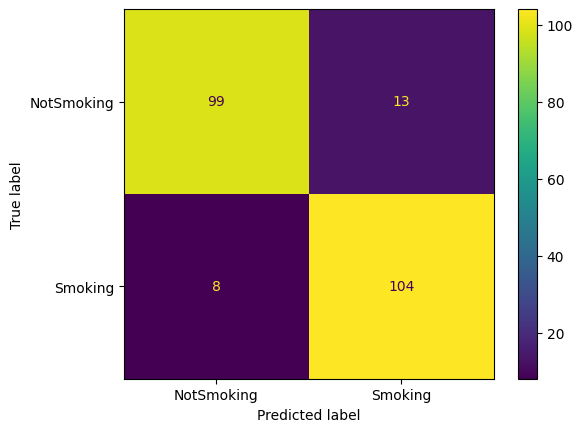

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_test, y_pred, target_names=le.classes_))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_)